In [1]:
import pandas as pd
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# Compare the immune cell features against both MTAP and BAP1 status
# using the three deconvolution outputs available in the dataset.

df = pd.read_csv('/home/rt334/Downloads/MEDUSA_Master_ULTIMATE.csv', low_memory=False)

# Set up the two grouping variables used for the comparisons.
mtap_col = 'DriverLoss 9p21 (CDKN2A,MTAP,IFNA)'
bap1_col = 'Overall BAP1 IHC (1=positive/retained, 0=negative/loss)'
df[mtap_col] = pd.to_numeric(df[mtap_col], errors='coerce')
df[bap1_col] = pd.to_numeric(df[bap1_col], errors='coerce')

# Pull out all immune features generated by Cibersort, ConsensusTME and xCell.
immune_cols = [c for c in df.columns if c.startswith(('Cibersort:', 'ConsensusTME:', 'xCell:'))]
print(f"Testing {len(immune_cols)} immune cell type columns\n")


# Run the same Mann-Whitney comparison across every immune feature.
def run_comparison(group_col, group_name, group0_label, group1_label):
    results = []
    for c in immune_cols:
        vals = pd.to_numeric(df[c], errors='coerce')
        sub = pd.DataFrame({c: vals, group_col: df[group_col]}).dropna()
        g0 = sub[sub[group_col] == 0][c]
        g1 = sub[sub[group_col] == 1][c]

        # Skip features where there are too few patients to make a useful comparison.
        if len(g0) < 3 or len(g1) < 3:
            continue

        u, p = mannwhitneyu(g0, g1)

        # Keep the sample sizes, group medians and p-value for each feature.
        results.append({
            'Immune feature': c,
            f'n ({group0_label})': len(g0),
            f'n ({group1_label})': len(g1),
            f'Median ({group0_label})': round(g0.median(), 4),
            f'Median ({group1_label})': round(g1.median(), 4),
            'p-value': p
        })

    out = pd.DataFrame(results)

    # Correct for testing a large number of immune features at the same time.
    out['FDR'] = multipletests(out['p-value'], method='fdr_bh')[1]
    out = out.sort_values('p-value')

    # Print the strongest results and a quick summary of significance.
    print(f"=== Immune microenvironment vs {group_name} ===")
    print(out.head(10).to_string(index=False))
    print(f"Nominally significant (p<0.05): {(out['p-value']<0.05).sum()} / {len(out)}")
    print(f"FDR-significant (FDR<0.05): {(out['FDR']<0.05).sum()} / {len(out)}\n")
    return out


# Run the analysis for MTAP and save the full result table.
mtap_results = run_comparison(mtap_col, 'MTAP status', 'intact', 'lost')
mtap_results.to_csv('table_immune_vs_mtap.csv', index=False)

# Repeat the same analysis for BAP1.
bap1_results = run_comparison(bap1_col, 'BAP1 status', 'retained', 'loss')
bap1_results.to_csv('table_immune_vs_bap1.csv', index=False)

# Confirm both output files were created.
print("saved: table_immune_vs_mtap.csv, table_immune_vs_bap1.csv")

Testing 77 immune cell type columns

=== Immune microenvironment vs MTAP status ===
                     Immune feature  n (intact)  n (lost)  Median (intact)  Median (lost)  p-value      FDR
Cibersort:Dendritic cells activated          46        70           0.0044         0.0000 0.000277 0.021361
           Cibersort:Macrophages M1          46        70           0.0186         0.0353 0.003769 0.145118
                    xCell:Th2 cells          46        70           0.0440         0.0949 0.007978 0.204766
            Cibersort:B cells naive          46        70           0.0714         0.0538 0.040748 0.602585
           ConsensusTME:Endothelial          46        70           0.5047         0.4723 0.050516 0.602585
           Cibersort:B cells memory          46        70           0.0000         0.0000 0.057356 0.602585
                  xCell:StromaScore          46        70           0.0205         0.0090 0.067868 0.602585
            xCell:Endothelial cells          46     

saved table_4_3_immune_vs_mtap.png


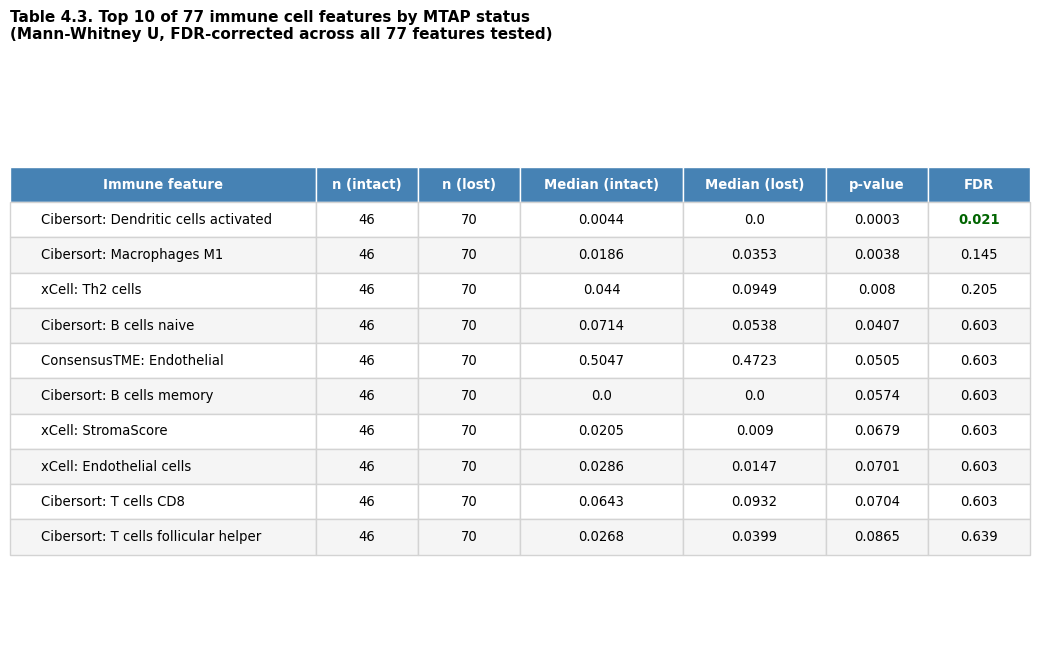

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Show the strongest immune associations with MTAP status
# and highlight any result that still remains significant after FDR correction.

df = pd.read_csv('table_immune_vs_mtap.csv')

# Keep the ten smallest p-values for the summary table
top = df.nsmallest(10, 'p-value').copy()

# Tidy up the labels and round the values so the table is easier to read
top['Immune feature'] = top['Immune feature'].str.replace(':', ': ')
top['p-value'] = top['p-value'].round(4)
top['FDR'] = top['FDR'].round(3)
top['Median (intact)'] = top['Median (intact)'].round(4)
top['Median (lost)'] = top['Median (lost)'].round(4)

# Set the figure height based on the number of rows
fig, ax = plt.subplots(figsize=(10.5, 0.5 * len(top) + 1.8))
ax.axis('off')

col_labels = list(top.columns)
cell_text = top.astype(str).values.tolist()

# Build the table
table = ax.table(
    cellText=cell_text,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
    colWidths=[0.30, 0.10, 0.10, 0.16, 0.14, 0.10, 0.10]
)

table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1, 1.85)

# Format the header
for col_idx in range(len(col_labels)):
    cell = table[0, col_idx]
    cell.set_facecolor('steelblue')
    cell.set_text_props(color='white', fontweight='bold')
    cell.set_edgecolor('white')

# Shade alternate rows and make significant FDR values stand out
fdr_idx = col_labels.index('FDR')

for row_idx in range(1, len(top) + 1):
    fdr_val = float(cell_text[row_idx - 1][fdr_idx])

    for col_idx in range(len(col_labels)):
        cell = table[row_idx, col_idx]
        cell.set_edgecolor('lightgrey')
        cell.set_facecolor('whitesmoke' if row_idx % 2 == 0 else 'white')

        if col_idx == 0:
            cell.set_text_props(ha='left')

        if col_idx == fdr_idx and fdr_val < 0.05:
            cell.set_text_props(fontweight='bold', color='darkgreen')

# Add the table title and save the finished version
plt.title(
    "Table 4.3. Top 10 of 77 immune cell features by MTAP status\n"
    "(Mann-Whitney U, FDR-corrected across all 77 features tested)",
    fontsize=11,
    fontweight='bold',
    pad=16,
    loc='left'
)

plt.tight_layout()
plt.savefig(
    'table_4_3_immune_vs_mtap.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

print('saved table_4_3_immune_vs_mtap.png')

/tmp/ipykernel_7140/642434004.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['MTAP_status'] = df[mtap_col].map({0: 'Intact', 1: 'Lost'})
/tmp/ipykernel_7140/642434004.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='MTAP_status', y=dc_col, order=['Intact', 'Lost'],


saved figure_4_9_dendritic_cells.png


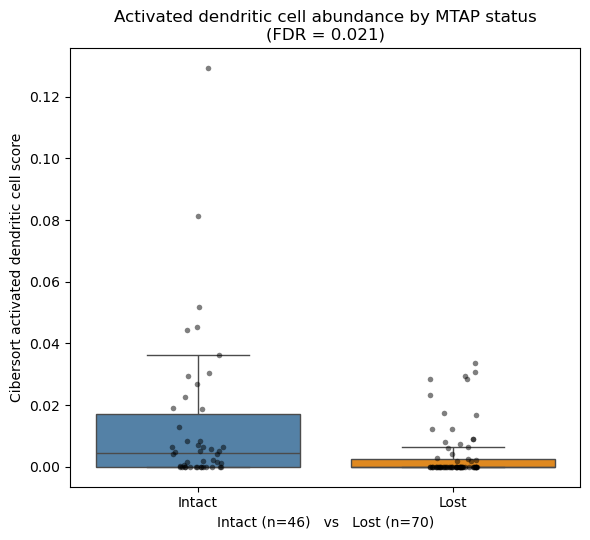

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the immune feature that remained significant after FDR correction

df = pd.read_csv('/home/rt334/Downloads/MEDUSA_Master_ULTIMATE.csv', low_memory=False)

# Separate the patients into MTAP-intact and MTAP-loss groups
mtap_col = 'DriverLoss 9p21 (CDKN2A,MTAP,IFNA)'
df[mtap_col] = pd.to_numeric(df[mtap_col], errors='coerce')
df['MTAP_status'] = df[mtap_col].map({0: 'Intact', 1: 'Lost'})

# Pull out the activated dendritic cell values and remove missing data
dc_col = 'Cibersort:Dendritic cells activated'
df[dc_col] = pd.to_numeric(df[dc_col], errors='coerce')
plot_df = df[[dc_col, 'MTAP_status']].dropna()

# Count how many patients are available in each group
n0 = (plot_df['MTAP_status'] == 'Intact').sum()
n1 = (plot_df['MTAP_status'] == 'Lost').sum()

# Show the group distributions with the individual patient values overlaid
fig, ax = plt.subplots(figsize=(6, 5.5))
sns.boxplot(data=plot_df, x='MTAP_status', y=dc_col, order=['Intact', 'Lost'],
            palette={'Intact': 'steelblue', 'Lost': 'darkorange'}, showfliers=False, ax=ax)
sns.stripplot(data=plot_df, x='MTAP_status', y=dc_col, order=['Intact', 'Lost'],
              color='black', alpha=0.5, size=4, ax=ax)

# Add the result and sample sizes directly to the figure
ax.set_title('Activated dendritic cell abundance by MTAP status\n(FDR = 0.021)')
ax.set_xlabel(f'Intact (n={n0})   vs   Lost (n={n1})')
ax.set_ylabel('Cibersort activated dendritic cell score')

# Save the finished figure
plt.tight_layout()
plt.savefig('figure_4_9_dendritic_cells.png', dpi=300, bbox_inches='tight')
print('saved figure_4_9_dendritic_cells.png')